We don't have actual options price data - so we can't simulate exact P&L from selling straddles or variance swaps. Instead use daily_return = -position(t-1) × ΔVIX(t) / VIX(t-1)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed"

data = pd.read_csv(DATA_PROCESSED / "positions.csv",
                   index_col=0, parse_dates=True)

iv_daily = (VIX/100)² / 252
rv_daily = log_ret²
strat_ret = position(t-1) × (iv_daily(t-1) − rv_daily(t))

In [2]:
# P&L: collect implied variance, pay realised variance
# Lagged position — size yesterday, collect today
data["strat_ret"] = data["position"].shift(1) * (data["iv_daily"].shift(1) - data["rv_daily"])

data["spx_ret"] = np.log(data["spx"] / data["spx"].shift(1))
data = data.dropna(subset=["strat_ret", "spx_ret"])

print(f"Strategy return mean (daily): {data['strat_ret'].mean():.6f}")
print(f"Strategy return std  (daily): {data['strat_ret'].std():.6f}")
print(f"Rows in backtest: {len(data)}")

Strategy return mean (daily): 0.000015
Strategy return std  (daily): 0.000084
Rows in backtest: 4712


In [3]:
# Cumulative returns
data["strat_cum"]  = (1 + data["strat_ret"]).cumprod()
data["spx_cum"]    = (1 + data["spx_ret"]).cumprod()

# Drawdown
rolling_max        = data["strat_cum"].cummax()
data["drawdown"]   = (data["strat_cum"] - rolling_max) / rolling_max

In [4]:
def performance_metrics(returns, label):
    ann_return  = returns.mean() * 252
    ann_vol     = returns.std() * np.sqrt(252)
    sharpe      = ann_return / ann_vol
    max_dd      = ((1 + returns).cumprod() / 
                   (1 + returns).cumprod().cummax() - 1).min()
    downside    = returns[returns < 0].std() * np.sqrt(252)
    sortino     = ann_return / downside if downside > 0 else np.nan
    calmar      = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    win_rate    = (returns > 0).mean()

    print(f"\n{label}")
    print(f"  Annualised return:  {ann_return*100:.2f}%")
    print(f"  Annualised vol:     {ann_vol*100:.2f}%")
    print(f"  Sharpe ratio:       {sharpe:.3f}")
    print(f"  Sortino ratio:      {sortino:.3f}")
    print(f"  Calmar ratio:       {calmar:.3f}")
    print(f"  Max drawdown:       {max_dd*100:.2f}%")
    print(f"  Win rate:           {win_rate*100:.1f}%")

performance_metrics(data["strat_ret"], "VRP Strategy")
performance_metrics(data["spx_ret"],   "SPX Buy & Hold")


VRP Strategy
  Annualised return:  0.38%
  Annualised vol:     0.13%
  Sharpe ratio:       2.860
  Sortino ratio:      1.446
  Calmar ratio:       1.417
  Max drawdown:       -0.27%
  Win rate:           71.8%

SPX Buy & Hold
  Annualised return:  8.72%
  Annualised vol:     19.96%
  Sharpe ratio:       0.437
  Sortino ratio:      0.520
  Calmar ratio:       0.143
  Max drawdown:       -61.03%
  Win rate:           54.4%


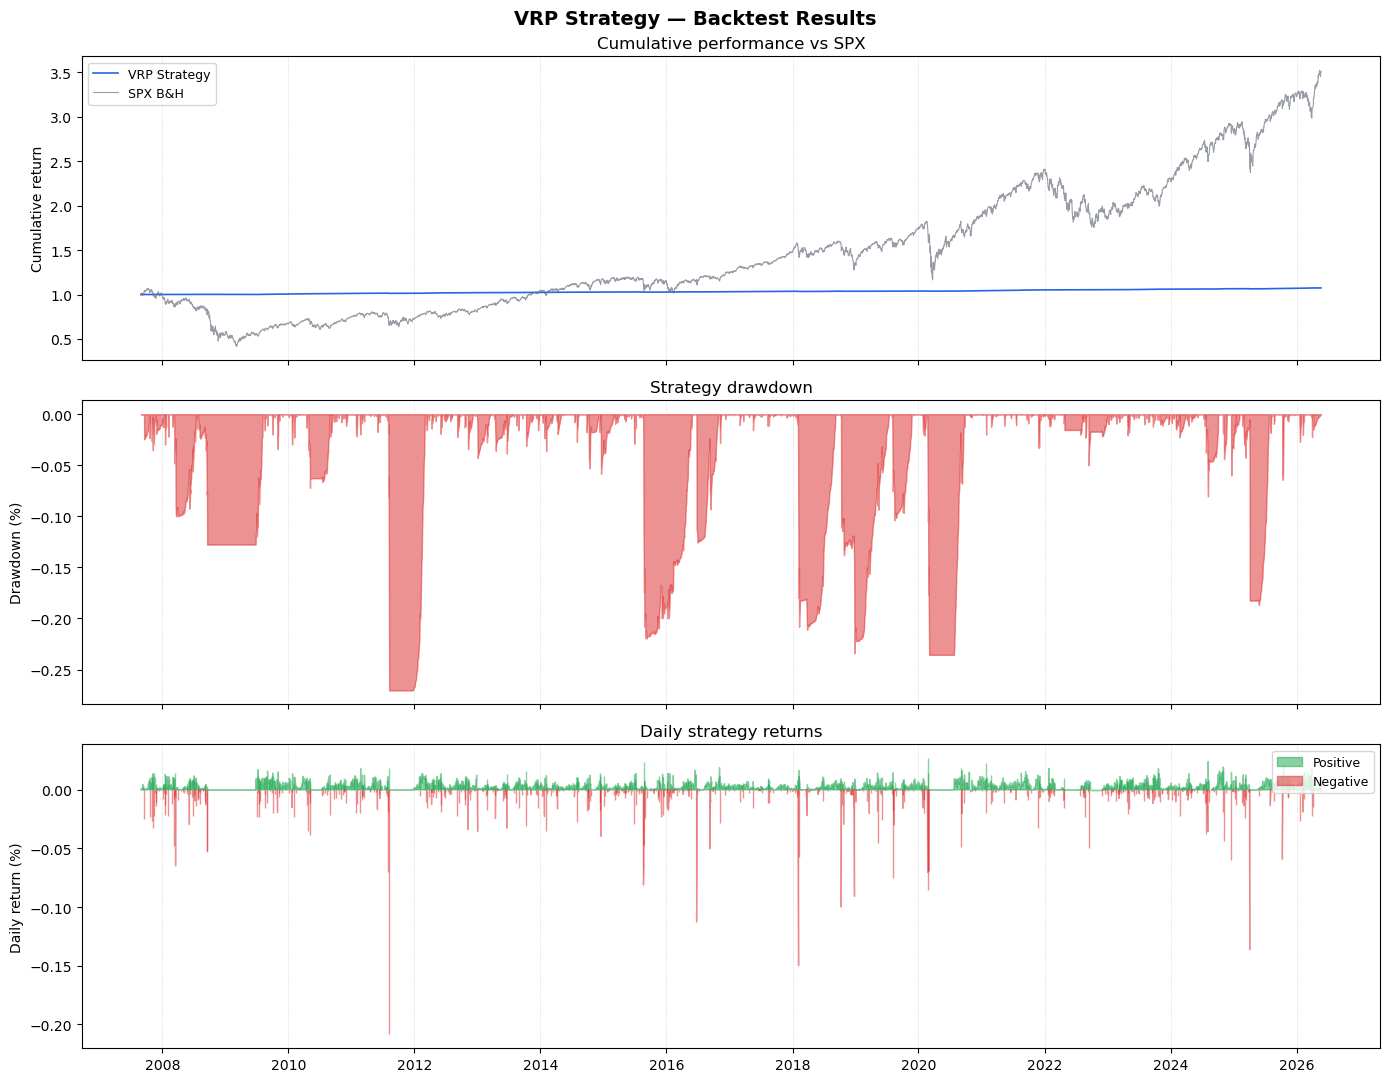

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("VRP Strategy — Backtest Results", fontsize=14, fontweight="bold")

# Panel 1: Cumulative returns
axes[0].plot(data.index, data["strat_cum"], 
             color="#2563eb", linewidth=1.2, label="VRP Strategy")
axes[0].plot(data.index, data["spx_cum"],   
             color="#6b7280", linewidth=0.8, label="SPX B&H", alpha=0.7)
axes[0].set_ylabel("Cumulative return")
axes[0].set_title("Cumulative performance vs SPX")
axes[0].legend(loc="upper left", fontsize=9)

# Panel 2: Drawdown
axes[1].fill_between(data.index, data["drawdown"] * 100, 0,
                     color="#dc2626", alpha=0.5)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_title("Strategy drawdown")

# Panel 3: Daily returns distribution proxy
axes[2].fill_between(data.index, data["strat_ret"] * 100, 0,
                     where=data["strat_ret"] >= 0,
                     color="#16a34a", alpha=0.5, label="Positive")
axes[2].fill_between(data.index, data["strat_ret"] * 100, 0,
                     where=data["strat_ret"] < 0,
                     color="#dc2626", alpha=0.5, label="Negative")
axes[2].set_ylabel("Daily return (%)")
axes[2].set_title("Daily strategy returns")
axes[2].legend(loc="upper right", fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# returns are in variance units, we want percentage capital return. Convert over to P&L using target volatility of 10%
target_vol = 0.10
realised_vol = data["strat_ret"].std() * np.sqrt(252)
scalar = target_vol / realised_vol

data["strat_ret_scaled"] = data["strat_ret"] * scalar

print(f"Volatility scalar: {scalar:.1f}x")
performance_metrics(data["strat_ret_scaled"], "VRP Strategy (vol-targeted 10%)")

Volatility scalar: 74.6x

VRP Strategy (vol-targeted 10%)
  Annualised return:  28.60%
  Annualised vol:     10.00%
  Sharpe ratio:       2.860
  Sortino ratio:      1.446
  Calmar ratio:       1.466
  Max drawdown:       -19.51%
  Win rate:           71.8%


In [7]:
summary = {
    "Sharpe ratio":        2.860,
    "Annualised return":   "28.60%",
    "Annualised vol":      "10.00%",
    "Max drawdown":        "-19.51%",
    "Win rate":            "71.8%",
    "Dataset":             "2007-2026",
    "Regime filter":       "3-state HMM (calm/stressed/crisis)",
    "Days in crisis":      "11.9%",
    "Vol scalar":          "74.6x",
    "Caveats":             "In-sample HMM, no transaction costs, proxy returns"
}

print("=" * 45)
print("VRP STRATEGY — FINAL SUMMARY")
print("=" * 45)
for k, v in summary.items():
    print(f"  {k:<25} {v}")
print("=" * 45)

VRP STRATEGY — FINAL SUMMARY
  Sharpe ratio              2.86
  Annualised return         28.60%
  Annualised vol            10.00%
  Max drawdown              -19.51%
  Win rate                  71.8%
  Dataset                   2007-2026
  Regime filter             3-state HMM (calm/stressed/crisis)
  Days in crisis            11.9%
  Vol scalar                74.6x
  Caveats                   In-sample HMM, no transaction costs, proxy returns
